### 第1题 线性隐藏层的多层感知机等价推导

已知网络结构：
1. 隐藏层输出：$\boldsymbol{h} = \mathbf{W}_1 \boldsymbol{x} + \mathbf{b}_1$
2. 输出层输出：$\boldsymbol{o} = \mathbf{W}_2 \boldsymbol{h} + \mathbf{b}_2$

将隐藏层代入输出层：
$$
\begin{align*}
\boldsymbol{o} &= \mathbf{W}_2 (\mathbf{W}_1 \boldsymbol{x} + \mathbf{b}_1) + \mathbf{b}_2 \\
&= (\mathbf{W}_2 \mathbf{W}_1) \boldsymbol{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)
\end{align*}
$$

令：
$$
\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1,\quad \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
$$

则：
$$
\boldsymbol{o} = \mathbf{W}' \boldsymbol{x} + \mathbf{b}'
$$

**结论**：无激活函数的单隐藏层多层感知机等价于一个单层线性神经网络。

### 第2题 Sigmoid 与 tanh 函数及导数

#### 1. Sigmoid 函数
定义：
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

导数推导：
$$
\begin{align*}
\sigma'(x) &= \frac{d}{dx}\left(\frac{1}{1+e^{-x}}\right) \\
&= \frac{e^{-x}}{(1+e^{-x})^2} \\
&= \sigma(x)(1-\sigma(x))
\end{align*}
$$

最终导数：
$$
\sigma'(x) = \sigma(x)(1-\sigma(x))
$$

---

#### 2. tanh 函数
定义：
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

导数推导：
$$
\begin{align*}
\tanh'(x) &= \frac{(e^x+e^{-x})^2 - (e^x-e^{-x})^2}{(e^x+e^{-x})^2} \\
&= \frac{4}{(e^x+e^{-x})^2} \\
&= 1 - \tanh^2(x)
\end{align*}
$$

最终导数：
$$
\tanh'(x) = 1 - \tanh^2(x)

100.0%
100.0%
100.0%
100.0%


Epoch 1/10, Train Loss: 1.0437, Train Acc: 0.6309, Test Acc: 0.7507
Epoch 2/10, Train Loss: 0.6020, Train Acc: 0.7889, Test Acc: 0.7775
Epoch 3/10, Train Loss: 0.5231, Train Acc: 0.8163, Test Acc: 0.7846
Epoch 4/10, Train Loss: 0.4802, Train Acc: 0.8323, Test Acc: 0.8246
Epoch 5/10, Train Loss: 0.4523, Train Acc: 0.8396, Test Acc: 0.8094
Epoch 6/10, Train Loss: 0.4338, Train Acc: 0.8472, Test Acc: 0.8391
Epoch 7/10, Train Loss: 0.4171, Train Acc: 0.8532, Test Acc: 0.8435
Epoch 8/10, Train Loss: 0.4033, Train Acc: 0.8567, Test Acc: 0.8364
Epoch 9/10, Train Loss: 0.3929, Train Acc: 0.8616, Test Acc: 0.8386
Epoch 10/10, Train Loss: 0.3829, Train Acc: 0.8645, Test Acc: 0.8454


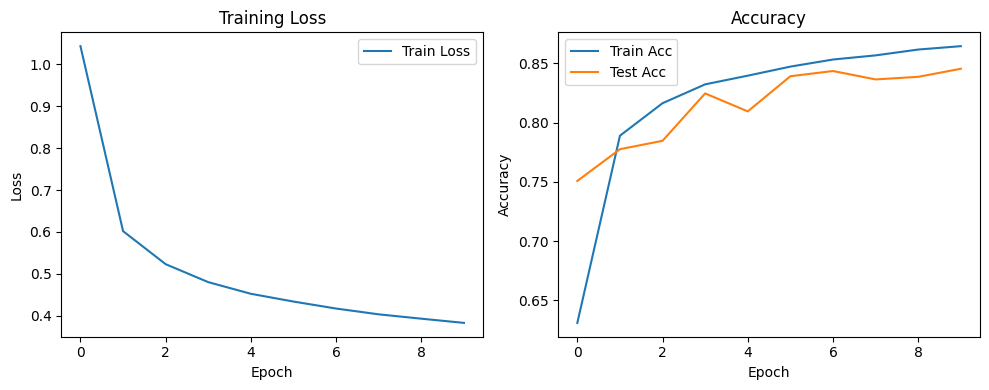

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# --------------------------
# 1. 数据准备 (Fashion-MNIST)
# --------------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # 转为 [0,1] 的 tensor
    transforms.Lambda(lambda x: x.flatten())  # 28x28 -> 784 维向量
])

# 加载训练/测试集
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 256
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

# --------------------------
# 2. 手动初始化参数
# --------------------------
input_dim = 784    # 28*28
hidden_dim = 256   # 隐藏层大小
output_dim = 10    # 10 分类

# 正态分布初始化权重，偏置初始化为0
W1 = torch.randn(input_dim, hidden_dim) * 0.01  # 输入层 -> 隐藏层
b1 = torch.zeros(1, hidden_dim)
W2 = torch.randn(hidden_dim, output_dim) * 0.01 # 隐藏层 -> 输出层
b2 = torch.zeros(1, output_dim)

# 开启自动求导
W1.requires_grad = True
b1.requires_grad = True
W2.requires_grad = True
b2.requires_grad = True

params = [W1, b1, W2, b2]

# --------------------------
# 3. 定义激活函数和损失函数
# --------------------------
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax(x):
    # 防止数值溢出，减去每行最大值
    max_vals = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_vals)
    sum_exp = torch.sum(exp_x, dim=1, keepdim=True)
    return exp_x / sum_exp

def cross_entropy_loss(logits, labels):
    """
    logits: 模型输出（未 softmax）, shape [batch, 10]
    labels: 真实标签, shape [batch]
    """
    batch_size = logits.shape[0]
    probs = softmax(logits)
    # 取出对应类别的概率
    label_probs = probs[torch.arange(batch_size), labels]
    # 交叉熵损失
    loss = -torch.mean(torch.log(label_probs + 1e-10))  # +1e-10 防止 log(0)
    return loss

# --------------------------
# 4. 训练循环 (Mini-batch SGD)
# --------------------------
learning_rate = 0.1
epochs = 10

train_loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        batch_size = x.shape[0]
        # 前向传播
        h = relu(x @ W1 + b1)        # 隐藏层
        logits = h @ W2 + b2         # 输出层
        loss = cross_entropy_loss(logits, y)

        # 反向传播
        loss.backward()

        # 手动更新参数（SGD）
        with torch.no_grad():
            for p in params:
                p -= learning_rate * p.grad
                p.grad.zero_()  # 梯度清零

        # 统计训练指标
        total_loss += loss.item() * batch_size
        _, predicted = torch.max(logits, dim=1)
        correct += (predicted == y).sum().item()
        total += batch_size

    # 训练集指标
    train_loss = total_loss / total
    train_acc = correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # 测试集评估
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for x, y in test_loader:
            h = relu(x @ W1 + b1)
            logits = h @ W2 + b2
            _, predicted = torch.max(logits, dim=1)
            test_correct += (predicted == y).sum().item()
            test_total += y.shape[0]
    test_acc = test_correct / test_total
    test_acc_history.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, "
          f"Test Acc: {test_acc:.4f}")

# --------------------------
# 5. 可视化训练过程
# --------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label="Train Acc")
plt.plot(test_acc_history, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

#### 1. 训练误差与泛化误差的区别
- **训练误差（Training Error）**：模型在**训练数据集**上计算得到的误差，反映模型对训练数据的拟合程度，衡量模型在已见过数据上的表现。
- **泛化误差（Generalization Error）**：模型在**未见过的独立测试/真实数据**上的误差，反映模型对新数据的适应能力，是衡量模型实际应用价值的核心指标。

两者的本质区别：训练误差仅反映模型对训练数据的记忆能力，而泛化误差反映模型的通用能力。

#### 2. 训练误差极低但泛化误差很高的状态
此时模型处于**过拟合（Overfitting）**状态：模型过度学习了训练数据中的噪声、特例和样本无关特征，甚至“记住”了训练数据，导致在新数据上表现极差。

#### 3. 通过控制模型复杂度缓解过拟合的方法
1.  **降低模型复杂度**：减少网络层数、隐藏层神经元数量，或使用更简单的模型（如从深层网络改为浅层网络），避免模型容量过高。
2.  **增加数据量/数据增强**：提供更多训练数据，或通过数据增强（如图像的旋转、裁剪）扩展数据分布，让模型无法轻易记住所有样本。
3.  **正则化约束**：
    - 权重衰减（L1/L2正则化）：在损失函数中加入权重的惩罚项，限制参数的大小，防止权重过大。
    - Dropout：训练时随机让部分神经元失活，降低神经元间的共适应性，增强模型泛化能力。
4.  **提前停止（Early Stopping）**：在验证集误差开始上升时停止训练，避免模型在训练集上过度拟合。

K折交叉验证（K-fold Cross-Validation）是一种评估模型泛化能力、选择超参数的方法，具体实施步骤如下：

1.  **数据划分**：将整个数据集随机划分为 **K 个互不重叠、大小大致相等的子集（称为“折”，fold）**。
2.  **循环训练与验证**：
    1.  选择其中 **1 个子集作为验证集**，剩余的 **K-1 个子集合并作为训练集**。
    2.  在训练集上训练模型，得到一个模型实例。
    3.  用验证集评估该模型的性能，记录验证误差/指标。
    4.  重复上述过程，每次选择不同的子集作为验证集，共执行 **K 次**，确保每个子集都被用作一次验证集。
3.  **结果汇总**：将 K 次验证的误差/指标取平均值，作为模型的整体性能估计。

> 补充说明：常见K值为5或10，K越大，估计结果越稳定，但计算成本越高。该方法能有效避免单次划分训练/验证集的偶然性偏差，更可靠地评估模型泛化能力，也常用于超参数调优。

=== 1. 无正则化 ===
=== 2. 仅 L2 权重衰减 ===
=== 3. 仅 Dropout ===


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10524\2533395965.py:158: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10524\2533395965.py:158: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10524\2533395965.py:158: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10524\2533395965.py:158: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10524\2533395965.py:158: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykerne

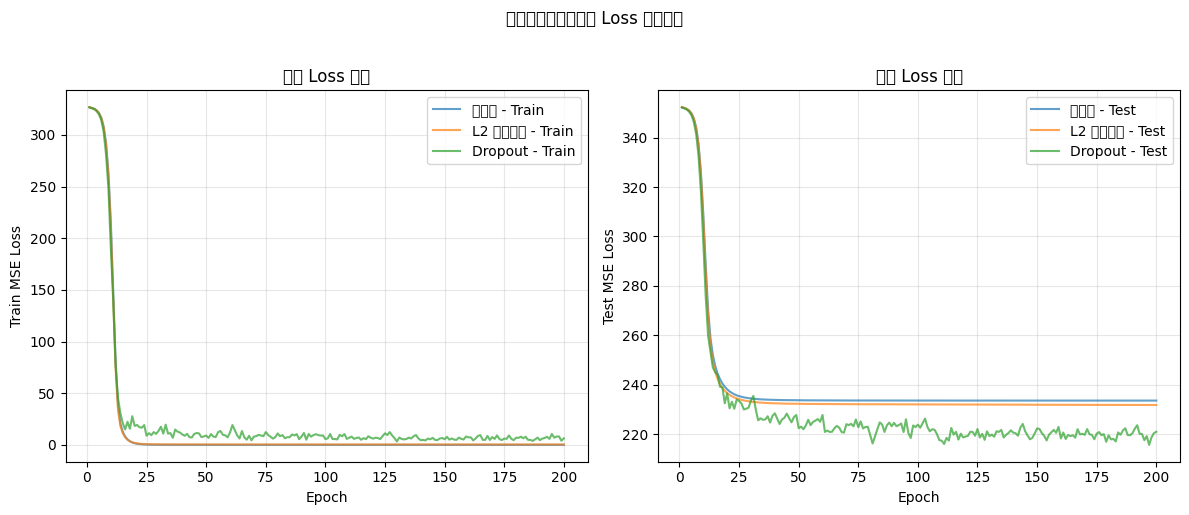

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. 构造高维多项式拟合数据（易过拟合场景）
# --------------------------
np.random.seed(42)
torch.manual_seed(42)

# 高维输入：100维多项式特征，少量样本
n_train = 50
n_test = 100
input_dim = 100  # 高维特征，容易过拟合

# 真实函数：简单的线性函数 + 噪声
def true_func(x):
    return 2 * x.sum(dim=1, keepdim=True) + 0.5

# 生成训练数据
x_train = torch.randn(n_train, input_dim)
y_train = true_func(x_train) + 0.1 * torch.randn(n_train, 1)

# 生成测试数据
x_test = torch.randn(n_test, input_dim)
y_test = true_func(x_test) + 0.1 * torch.randn(n_test, 1)

# --------------------------
# 2. 从零实现 Dropout 层
# --------------------------
def dropout_layer(X, dropout_prob, is_training=True):
    """
    X: 输入张量
    dropout_prob: 丢弃概率（0~1）
    is_training: 是否为训练模式，测试时不 dropout
    """
    if not is_training or dropout_prob == 0:
        return X
    # 生成随机掩码
    mask = (torch.rand(X.shape) > dropout_prob).float()
    # 缩放：保留的部分要乘以 1/(1-dropout_prob)，保证期望不变
    return mask * X / (1 - dropout_prob)

# --------------------------
# 3. 自定义带权重衰减的 SGD 更新
# --------------------------
def sgd_step(params, lr, weight_decay=0.0):
    """
    自定义SGD更新，带权重衰减
    params: 需要更新的参数列表
    lr: 学习率 η
    weight_decay: 权重衰减系数 λ
    """
    with torch.no_grad():
        for p in params:
            if weight_decay > 0:
                # 权重衰减：旧权重先乘 (1 - ηλ)
                p *= (1 - lr * weight_decay)
            # 再减去梯度更新
            p -= lr * p.grad
            p.grad.zero_()

# --------------------------
# 4. 定义训练函数（支持不同正则化）
# --------------------------
def train_mlp(use_l2=False, use_dropout=False, 
               hidden_dim=256, epochs=200, lr=0.01, 
               l2_lambda=0.001, dropout_prob=0.5):
    # 模型参数初始化
    W1 = torch.randn(input_dim, hidden_dim) * 0.01
    b1 = torch.zeros(1, hidden_dim)
    W2 = torch.randn(hidden_dim, 1) * 0.01
    b2 = torch.zeros(1, 1)

    for p in [W1, b1, W2, b2]:
        p.requires_grad = True

    params = [W1, b1, W2, b2]

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # 训练阶段
        # 前向传播
        h = F.relu(x_train @ W1 + b1)
        if use_dropout:
            h = dropout_layer(h, dropout_prob, is_training=True)
        y_pred = h @ W2 + b2

        # 计算损失（MSE）
        loss = F.mse_loss(y_pred, y_train)
        # 如果使用L2正则，手动添加惩罚项
        if use_l2:
            l2_penalty = l2_lambda * (torch.sum(W1**2) + torch.sum(W2**2))
            loss += l2_penalty

        # 反向传播 + 自定义SGD更新
        loss.backward()
        sgd_step(params, lr, weight_decay=l2_lambda if use_l2 else 0.0)

        # 测试阶段
        with torch.no_grad():
            h_test = F.relu(x_test @ W1 + b1)
            if use_dropout:
                h_test = dropout_layer(h_test, dropout_prob, is_training=False)
            y_pred_test = h_test @ W2 + b2
            test_loss = F.mse_loss(y_pred_test, y_test)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

    return train_losses, test_losses

# --------------------------
# 5. 对比实验：三种情况
# --------------------------
print("=== 1. 无正则化 ===")
train_no_reg, test_no_reg = train_mlp(use_l2=False, use_dropout=False)

print("=== 2. 仅 L2 权重衰减 ===")
train_l2, test_l2 = train_mlp(use_l2=True, use_dropout=False, l2_lambda=0.01)

print("=== 3. 仅 Dropout ===")
train_dropout, test_dropout = train_mlp(use_l2=False, use_dropout=True, dropout_prob=0.5)

# --------------------------
# 6. 绘制 Loss 曲线对比
# --------------------------
epochs = range(1, len(train_no_reg)+1)

plt.figure(figsize=(12, 5))

# 训练 Loss 对比
plt.subplot(1, 2, 1)
plt.plot(epochs, train_no_reg, label="无正则 - Train", alpha=0.7)
plt.plot(epochs, train_l2, label="L2 权重衰减 - Train", alpha=0.7)
plt.plot(epochs, train_dropout, label="Dropout - Train", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Train MSE Loss")
plt.title("训练 Loss 对比")
plt.legend()
plt.grid(alpha=0.3)

# 验证 Loss 对比
plt.subplot(1, 2, 2)
plt.plot(epochs, test_no_reg, label="无正则 - Test", alpha=0.7)
plt.plot(epochs, test_l2, label="L2 权重衰减 - Test", alpha=0.7)
plt.plot(epochs, test_dropout, label="Dropout - Test", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Test MSE Loss")
plt.title("测试 Loss 对比")
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("不同正则化策略下的 Loss 曲线对比", y=1.02)
plt.tight_layout()
plt.show()

### 第1题 梯度消失与梯度爆炸的量化分析

深度神经网络反向传播过程中，梯度可表示为多层偏导的连乘形式：
$$
\frac{\partial \boldsymbol{h}^{d}}{\partial \boldsymbol{h}^{t}} = \prod_{i=t}^{d-1} \frac{\partial \boldsymbol{h}^{i+1}}{\partial \boldsymbol{h}^{i}}
$$
单层梯度关系：
$$
\frac{\partial \boldsymbol{h}^{i+1}}{\partial \boldsymbol{h}^{i}} = \boldsymbol{W}^{i} \odot \sigma'(\boldsymbol{z}^{i})
$$
其中 $\boldsymbol{W}^i$ 为第$i$层权重，$\sigma'(\cdot)$ 为激活函数导数，$\boldsymbol{z}^i = \boldsymbol{W}^i \boldsymbol{h}^i + \boldsymbol{b}^i$。

#### 1. 梯度爆炸
若每层梯度项的**谱范数/特征值大于 1**，多层连乘后梯度会指数级增大。
- 权重矩阵特征值普遍大于 1，矩阵运算不断放大梯度；
- 部分激活函数区间导数大于 1，进一步加剧放大效果。
- 量化表现：$\displaystyle \left\|\prod_{i=t}^{d-1} \frac{\partial \boldsymbol{h}^{i+1}}{\partial \boldsymbol{h}^{i}}\right\| \propto \lambda^{d-t},\ \lambda>1$，网络越深梯度越大，参数更新震荡、训练发散。

#### 2. 梯度消失
若每层梯度项的**谱范数/特征值小于 1**，多层连乘后梯度会指数级趋近于 0。
- Sigmoid 导数范围 $(0,0.25]$、tanh 导数范围 $(0,1]$，输入进入饱和区时导数接近 0；
- 权重矩阵特征值偏小，叠加激活函数小导数，梯度不断衰减。
- 量化表现：$\displaystyle \left\|\prod_{i=t}^{d-1} \frac{\partial \boldsymbol{h}^{i+1}}{\partial \boldsymbol{h}^{i}}\right\| \propto \lambda^{d-t},\ \lambda<1$，深层网络梯度几乎为 0，参数无法更新，训练停滞。

---

### 第2题 ReLU 缓解梯度消失的原理
ReLU 函数定义：
$$
\text{ReLU}(x) = \max(0, x)
$$
导数：
$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$

1. **正区间导数恒为 1**
当输入 $x>0$ 时，导数固定为 1，多层反向传播连乘后梯度不会被持续缩小，从根源上避免梯度逐层衰减。
2. **无梯度饱和问题**
相较于 Sigmoid、tanh，ReLU 不存在两端饱和区域，大部分有效输入区间能保证梯度正常传递。

> 补充缺点：输入 $x\le0$ 时导数为 0，易出现**神经元死亡**问题。

=== 1. Sigmoid + 普通高斯初始化 (std=1) ===

===== Sigmoid + Normal(std=1) =====
Layer  1 | Gradient Norm: 4.298845e+02
Layer  3 | Gradient Norm: 2.555786e+02
Layer  5 | Gradient Norm: 2.028811e+02
Layer  7 | Gradient Norm: 1.533653e+02
Layer  9 | Gradient Norm: 1.160559e+02
Layer 11 | Gradient Norm: 8.039745e+01
Layer 13 | Gradient Norm: 6.503272e+01
Layer 15 | Gradient Norm: 5.065371e+01
Layer 17 | Gradient Norm: 4.261153e+01
Layer 19 | Gradient Norm: 3.465321e+01
Layer 21 | Gradient Norm: 2.982365e+01
Layer 23 | Gradient Norm: 2.542273e+01
Layer 25 | Gradient Norm: 1.651518e+01
Layer 27 | Gradient Norm: 1.335524e+01
Layer 29 | Gradient Norm: 1.146009e+01
Layer 31 | Gradient Norm: 8.202493e+00
Layer 33 | Gradient Norm: 7.916822e+00
Layer 35 | Gradient Norm: 7.595942e+00
Layer 37 | Gradient Norm: 6.101023e+00
Layer 39 | Gradient Norm: 5.675892e+00
Layer 41 | Gradient Norm: 6.438220e+00

=== 2. ReLU + 大初始值 (std=10) ===

===== ReLU + Normal(std=10) =====
Layer  1 | Gradient Norm: nan
Layer  3 

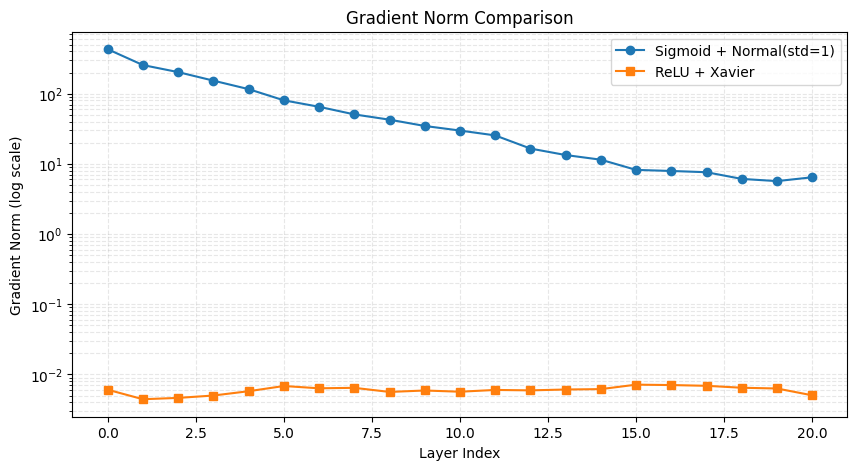

In [2]:
import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np

# --------------------------
# 通用函数：构建 20 层全连接网络
# --------------------------
def build_deep_net(activation_fn, init_func=None, hidden_dim=256, num_layers=20):
    layers = []
    # 输入层：假设输入为 784 维（类似 MNIST）
    in_dim = 784
    for i in range(num_layers):
        layers.append(nn.Linear(in_dim, hidden_dim))
        if activation_fn is not None:
            layers.append(activation_fn())
        in_dim = hidden_dim
    # 输出层（这里不影响梯度观察，仅为完整结构）
    layers.append(nn.Linear(hidden_dim, 10))
    net = nn.Sequential(*layers)

    # 应用初始化
    if init_func is not None:
        for m in net.modules():
            if isinstance(m, nn.Linear):
                init_func(m.weight)
                if m.bias is not None:
                    init.zeros_(m.bias)
    return net

# --------------------------
# 通用函数：前向+反向传播，打印各层梯度范数
# --------------------------
def check_gradients(net, x, y, desc=""):
    # 前向传播
    logits = net(x)
    loss = nn.CrossEntropyLoss()(logits, y)
    # 反向传播
    loss.backward()

    print(f"\n===== {desc} =====")
    grad_norms = []
    for i, m in enumerate(net.modules()):
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                norm = m.weight.grad.norm().item()
                grad_norms.append(norm)
                print(f"Layer {i:2d} | Gradient Norm: {norm:.6e}")
            else:
                grad_norms.append(0.0)
                print(f"Layer {i:2d} | Gradient Norm: None")
    return grad_norms

# --------------------------
# 准备随机输入数据
# --------------------------
batch_size = 32
x = torch.randn(batch_size, 784)
y = torch.randint(0, 10, (batch_size,))

# --------------------------
# 1. 情况一：Sigmoid + 普通高斯初始化（std=1）
# --------------------------
print("=== 1. Sigmoid + 普通高斯初始化 (std=1) ===")
net1 = build_deep_net(
    activation_fn=nn.Sigmoid,
    init_func=lambda w: init.normal_(w, mean=0, std=1)
)
grad_norms1 = check_gradients(net1, x, y, desc="Sigmoid + Normal(std=1)")
# 可以观察到：深层梯度几乎为 0（梯度消失）

# 清空梯度
for p in net1.parameters():
    p.grad = None

# --------------------------
# 2. 情况二：ReLU + 较大初始值（std=10）
# --------------------------
print("\n=== 2. ReLU + 大初始值 (std=10) ===")
net2 = build_deep_net(
    activation_fn=nn.ReLU,
    init_func=lambda w: init.normal_(w, mean=0, std=10)
)
try:
    grad_norms2 = check_gradients(net2, x, y, desc="ReLU + Normal(std=10)")
except RuntimeError as e:
    print(f"出现错误（通常是 NaN/inf，梯度爆炸）: {e}")

# 清空梯度
for p in net2.parameters():
    p.grad = None

# --------------------------
# 3. 情况三：Xavier 初始化 + ReLU（稳定版）
# --------------------------
print("\n=== 3. Xavier 初始化 + ReLU ===")
net3 = build_deep_net(
    activation_fn=nn.ReLU,
    init_func=init.xavier_uniform_
)
grad_norms3 = check_gradients(net3, x, y, desc="ReLU + Xavier Uniform")

# 清空梯度
for p in net3.parameters():
    p.grad = None

# --------------------------
# 可视化对比梯度范数
# --------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
layers = np.arange(len(grad_norms1))

plt.plot(layers, grad_norms1, label="Sigmoid + Normal(std=1)", marker='o')
plt.plot(layers, grad_norms3, label="ReLU + Xavier", marker='s')
plt.yscale("log")
plt.xlabel("Layer Index")
plt.ylabel("Gradient Norm (log scale)")
plt.title("Gradient Norm Comparison")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

### 5.1 理论计算题：协变量偏移与标签偏移的区别与联系

我们以**医疗影像诊断**场景为例，详细阐述两种环境非平稳性偏移的区别与联系。

---

#### 1. 协变量偏移（Covariate Shift）
**定义**：输入特征的边缘分布发生变化（$p(x) \neq q(x)$），但条件分布 $p(y|x) = q(y|x)$ 保持不变。
通俗理解：数据的“样子”变了，但“输入-标签的映射关系”没变。

**医疗例子**：
假设模型在 A 医院的胸片数据上训练，目标是根据胸片特征 $x$ 判断是否患有肺炎 $y$。
- 训练数据 $p(x)$：A 医院使用高分辨率新设备拍摄的胸片，图像清晰、噪声低。
- 测试数据 $q(x)$：B 医院使用老旧设备拍摄的胸片，图像模糊、噪声高，甚至存在不同的扫描参数。
- 此时，$p(x) \neq q(x)$（输入图像的分布不同），但肺炎与胸片特征的映射关系 $p(y|x)$ 并未改变（即“什么样的胸片特征代表肺炎”的医学标准是一致的）。

---

#### 2. 标签偏移（Label Shift）
**定义**：标签的边缘分布发生变化（$p(y) \neq q(y)$），但条件分布 $p(x|y) = q(x|y)$ 保持不变。
通俗理解：数据的“标签比例”变了，但“每个标签对应的输入特征分布”没变。

**医疗例子**：
假设模型在普通门诊的胸片数据上训练，目标同样是判断肺炎。
- 训练数据 $p(y)$：普通门诊患者中，肺炎患者比例低，健康患者占绝大多数。
- 测试数据 $q(y)$：疫情期间发热门诊的患者中，肺炎患者比例大幅上升，健康患者很少。
- 此时，$p(y) \neq q(y)$（肺炎/健康的标签比例不同），但“肺炎患者的胸片特征分布 $p(x|y=肺炎)$”和“健康患者的胸片特征分布 $p(x|y=健康)$”在两种场景下是一致的，即 $p(x|y) = q(x|y)$。

---

#### 3. 两者的核心区别
| 维度 | 协变量偏移 | 标签偏移 |
| :--- | :--- | :--- |
| 变化的分布 | 输入边缘分布 $p(x)$ | 标签边缘分布 $p(y)$ |
| 不变的分布 | 条件分布 $p(y|x)$ | 条件分布 $p(x|y)$ |
| 本质问题 | 输入特征的分布漂移 | 标签的先验分布漂移 |
| 典型场景 | 跨设备/跨采集环境的数据分布变化 | 不同疾病流行率、不同用户群体的标签比例变化 |

---

#### 4. 两者的联系
- **同属分布偏移**：两者都是训练集和测试集数据分布不一致的问题，都会导致模型泛化性能下降。
- **数学关系**：根据贝叶斯定理 $p(x,y)=p(x)p(y|x)=p(y)p(x|y)$，两种偏移都源于联合分布 $p(x,y)$ 发生了变化，只是变化的部分不同。
- **可利用的不变性**：
  - 协变量偏移中，我们可以利用 $p(y|x)$ 不变的特性，通过重要性加权（对训练数据按 $q(x)/p(x)$ 加权）来修正分布差异。
  - 标签偏移中，我们可以利用 $p(x|y)$ 不变的特性，通过估计测试集的标签先验 $q(y)$，再修正模型输出。

【基线模型】测试集 MSE: 0.2546
【加权校正模型】测试集 MSE: 0.6005


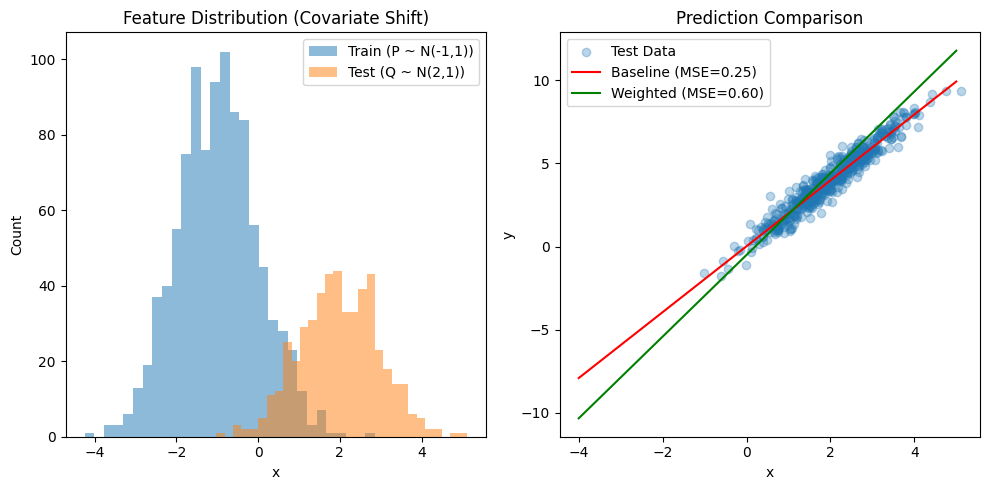

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------
# 1. 构造人工数据集：训练集 P 和测试集 Q（协变量偏移）
# ------------------------------------------------------
np.random.seed(42)

# 训练集 P: x ~ N(-1, 1), y = 2x + epsilon
n_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=(n_train, 1))
epsilon_train = np.random.normal(loc=0, scale=0.5, size=(n_train, 1))
y_train = 2 * x_train + epsilon_train

# 测试集 Q: x ~ N(2, 1), y = 2x + epsilon（同样的映射关系）
n_test = 500
x_test = np.random.normal(loc=2, scale=1, size=(n_test, 1))
epsilon_test = np.random.normal(loc=0, scale=0.5, size=(n_test, 1))
y_test = 2 * x_test + epsilon_test

# ------------------------------------------------------
# 2. 基线模型：普通线性回归
# ------------------------------------------------------
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)
y_pred_baseline = baseline_model.predict(x_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"【基线模型】测试集 MSE: {mse_baseline:.4f}")

# ------------------------------------------------------
# 3. 协变量偏移校正：使用逻辑回归估计权重
# ------------------------------------------------------
# (a) 构造二分类任务：训练集=0，测试集=1
X = np.vstack([x_train, x_test])
domain_labels = np.array([0]*n_train + [1]*n_test)

# 训练逻辑回归分类器，预测每个样本属于测试集的概率 P(test|x)
domain_clf = LogisticRegression()
domain_clf.fit(X, domain_labels)
p_test_given_x = domain_clf.predict_proba(x_train)[:, 1]  # 训练样本属于测试集的概率

# (b) 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
p_train_given_x = 1 - p_test_given_x
weights = p_test_given_x / p_train_given_x

# ------------------------------------------------------
# 4. 加权线性回归：使用权重重新训练模型
# ------------------------------------------------------
weighted_model = LinearRegression()
weighted_model.fit(x_train, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"【加权校正模型】测试集 MSE: {mse_weighted:.4f}")

# ------------------------------------------------------
# 5. 可视化对比
# ------------------------------------------------------
plt.figure(figsize=(10, 5))

# 数据分布
plt.subplot(1, 2, 1)
plt.hist(x_train, bins=30, alpha=0.5, label='Train (P ~ N(-1,1))')
plt.hist(x_test, bins=30, alpha=0.5, label='Test (Q ~ N(2,1))')
plt.xlabel('x')
plt.ylabel('Count')
plt.title('Feature Distribution (Covariate Shift)')
plt.legend()

# 拟合效果对比
plt.subplot(1, 2, 2)
x_line = np.linspace(-4, 5, 100).reshape(-1,1)
plt.scatter(x_test, y_test, alpha=0.3, label='Test Data')
plt.plot(x_line, baseline_model.predict(x_line), 'r-', label=f'Baseline (MSE={mse_baseline:.2f})')
plt.plot(x_line, weighted_model.predict(x_line), 'g-', label=f'Weighted (MSE={mse_weighted:.2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prediction Comparison')
plt.legend()

plt.tight_layout()
plt.show()